# Домашнее задание к занятию «Классификация: Логистическая регрессия и SVM»

Выполнил: Ярослав Золотухин

<b>Задача: решить задачу классификации физических лиц по уровню дохода </b>

In [255]:
%pip install pandas
%pip install numpy
%pip install matplotlib
%pip install sklearn

Defaulting to user installation because normal site-packages is not writeable
You should consider upgrading via the '/Library/Developer/CommandLineTools/usr/bin/python3 -m pip install --upgrade pip' command.
Note: you may need to restart the kernel to use updated packages.
Defaulting to user installation because normal site-packages is not writeable
You should consider upgrading via the '/Library/Developer/CommandLineTools/usr/bin/python3 -m pip install --upgrade pip' command.
Note: you may need to restart the kernel to use updated packages.
Defaulting to user installation because normal site-packages is not writeable
You should consider upgrading via the '/Library/Developer/CommandLineTools/usr/bin/python3 -m pip install --upgrade pip' command.
Note: you may need to restart the kernel to use updated packages.
Defaulting to user installation because normal site-packages is not writeable
You should consider upgrading via the '/Library/Developer/CommandLineTools/usr/bin/python3 -m pip in

In [256]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [257]:
data = pd.read_csv( 'adult.csv' )
data.head()

,age,workclass,fnlwgt,education,educational-num,marital-status,occupation,relationship,race,gender,capital-gain,capital-loss,hours-per-week,native-country,income
0,25,Private,226802,11th,7,Never-married,Machine-op-inspct,Own-child,Black,Male,0,0,40,United-States,<=50K
1,38,Private,89814,HS-grad,9,Married-civ-spouse,Farming-fishing,Husband,White,Male,0,0,50,United-States,<=50K
2,28,Local-gov,336951,Assoc-acdm,12,Married-civ-spouse,Protective-serv,Husband,White,Male,0,0,40,United-States,>50K
3,44,Private,160323,Some-college,10,Married-civ-spouse,Machine-op-inspct,Husband,Black,Male,7688,0,40,United-States,>50K
4,18,?,103497,Some-college,10,Never-married,?,Own-child,White,Female,0,0,30,United-States,<=50K


In [258]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 48842 entries, 0 to 48841
Data columns (total 15 columns):
 #   Column           Non-Null Count  Dtype 
---  ------           --------------  ----- 
 0   age              48842 non-null  int64 
 1   workclass        48842 non-null  object
 2   fnlwgt           48842 non-null  int64 
 3   education        48842 non-null  object
 4   educational-num  48842 non-null  int64 
 5   marital-status   48842 non-null  object
 6   occupation       48842 non-null  object
 7   relationship     48842 non-null  object
 8   race             48842 non-null  object
 9   gender           48842 non-null  object
 10  capital-gain     48842 non-null  int64 
 11  capital-loss     48842 non-null  int64 
 12  hours-per-week   48842 non-null  int64 
 13  native-country   48842 non-null  object
 14  income           48842 non-null  object
dtypes: int64(6), object(9)
memory usage: 5.6+ MB


Явные пропуски отсутствуют.

## Визуализация данных

Отобразим точечную диаграмму и рассмотрим уровень дохода в завимости от уровня образования с разбивкой по категориям. 
Так как уровень дохода у нас имеет только 2 значения, то отобразим их на графике различными цветами.

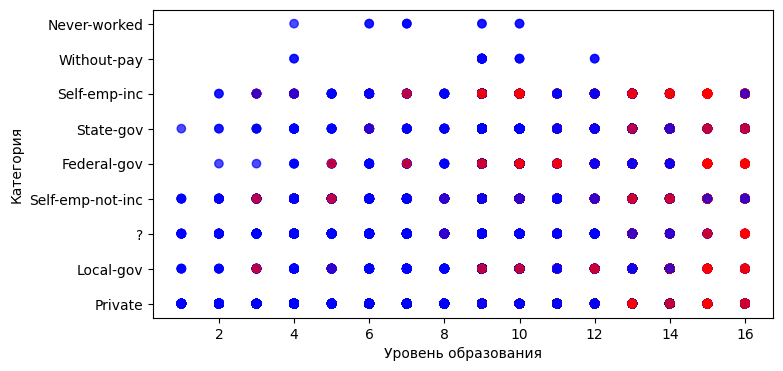

In [259]:
# Сопоставляем значениям income конкретные цвета
point_colors = data['income'].map({'<=50K': 'blue', '>50K': 'red'})

plt.figure(figsize=(8, 4))
plt.scatter(data['educational-num'], data['workclass'], c=point_colors, alpha=0.7)

plt.ylabel('Категория')
plt.xlabel('Уровень образования')
plt.show()

На данной диаграмме видно, что с ростом образования количество людей с высоким доходом превалирует для всех категорий.

Отобразим столбчатую диаграмму в разрезе пола.

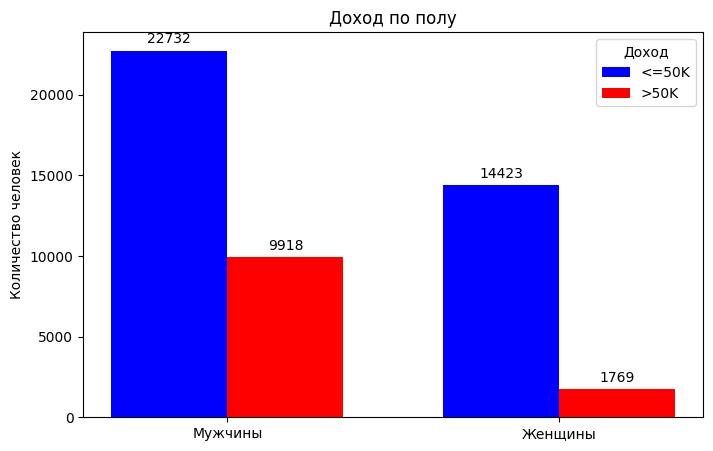

In [260]:
males = data[data['gender'] == 'Male']['income'].value_counts()
females = data[data['gender'] == 'Female']['income'].value_counts()

low_income = [males.get('<=50K', 0), females.get('<=50K', 0)]
high_income = [males.get('>50K', 0), females.get('>50K', 0)]

labels = ['Мужчины', 'Женщины']

x = np.arange(len(labels))  
width = 0.35                #  ширина столбцов

plt.figure(figsize=(8, 5))

bar1 = plt.bar(x - width/2, low_income, width, color='blue', label='<=50K')
plt.bar_label(bar1, padding=3)

bar2 = plt.bar(x + width/2, high_income, width, color='red', label='>50K')
plt.bar_label(bar2, padding=3)

plt.ylabel('Количество человек')
plt.title('Доход по полу')
plt.xticks(x, labels) # Устанавливаем текстовые метки ('Мужчины', 'Женщины') по центру
plt.legend(title='Доход')

plt.show()

## Шаг 3. Преобразование категориальных признаков

In [261]:
from sklearn.linear_model import LogisticRegression

In [262]:
selectedColumns = data[ [ 'educational-num', 'age', 'gender', 'hours-per-week',  'marital-status', 'occupation', 
                         'relationship', 'income' ] ]

# категориальные переменные
X = pd.get_dummies( selectedColumns, columns = [ 'gender', 'marital-status', 'occupation', 'relationship' ] )

# столбец income является целевой переменной, удаляем его из X
del X['income']
X.head()

,educational-num,age,hours-per-week,gender_Female,gender_Male,marital-status_Divorced,marital-status_Married-AF-spouse,marital-status_Married-civ-spouse,marital-status_Married-spouse-absent,marital-status_Never-married,...,occupation_Protective-serv,occupation_Sales,occupation_Tech-support,occupation_Transport-moving,relationship_Husband,relationship_Not-in-family,relationship_Other-relative,relationship_Own-child,relationship_Unmarried,relationship_Wife
0,7,25,40,False,True,False,False,False,False,True,...,False,False,False,False,False,False,False,True,False,False
1,9,38,50,False,True,False,False,True,False,False,...,False,False,False,False,True,False,False,False,False,False
2,12,28,40,False,True,False,False,True,False,False,...,True,False,False,False,True,False,False,False,False,False
3,10,44,40,False,True,False,False,True,False,False,...,False,False,False,False,True,False,False,False,False,False
4,10,18,30,True,False,False,False,False,False,True,...,False,False,False,False,False,False,False,True,False,False


In [263]:
# целевая переменная (столбец income) снова является категориальной
# переведем значения столбца в числа, оставив один столбец

from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()

In [264]:
le.fit( data['income'] )

LabelEncoder()

In [265]:
# записываем в переменную y преобразованный столбец income

y = pd.Series( data = le.transform( data['income'] ) )
y.head()

0    0
1    0
2    1
3    1
4    0
dtype: int64

## Шаг 4. Обучение

 Поделим данные на обучающую выборку и тестовую. На тестовую выборку оставляем 20%.

In [266]:
from sklearn.model_selection import train_test_split 

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

### Обучим модель логистической регрессии

In [267]:
model_logReg = LogisticRegression()

In [268]:
# обучаем модель

model_logReg.fit( X_train, y_train )
predictions = model_logReg.predict( X_test )

/Users/acer/Library/Python/3.9/lib/python/site-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


In [269]:
predictions

array([0, 0, 0, ..., 1, 0, 1])

In [270]:
model_logReg.predict_proba(X_test)

array([[0.98971   , 0.01029   ],
       [0.94817537, 0.05182463],
       [0.83944608, 0.16055392],
       ...,
       [0.34631389, 0.65368611],
       [0.9958957 , 0.0041043 ],
       [0.19947414, 0.80052586]])

Получаем наш скор (точность предсказания) на обучающей и тестовой выборках.

In [271]:
model_logReg.score(X_train, y_train) 

0.8302152381439869

In [272]:
model_logReg.score(X_test,y_test)

0.8405159176988433

### Обучим модель опорных векторов. SVM.

In [273]:
from sklearn.svm import SVC

model_svc = SVC()
model_svc.fit(X_train, y_train)

SVC()

In [274]:
model_svc.score(X_train, y_train) 

0.8275023673636527

In [275]:
model_svc.score(X_test, y_test)

0.8318149247620023

# Выводы по проделанной работе

В ходе данного домашнего задания был выполнен анализ файла adult.csv для решения задачи бинарной класификации, отображены графики по части признаков. 

- категориальные признаки преобразованы методом one-hot encoding (функция pd.get_dummies)
- Целевая переменная income (категории <=50K и >50K) закодирована в 0 и 1 с помощью LabelEncoder.
- Выборка разбита по принципу 80/20

После подготовки данных рассматривались 2 различные модели на идентичных данных, где

| Модель | Точность на обучении | Точность на тесте |
|--------|----------------------|-------------------|
| Логистическая регрессия | 0.8302 | 0.8405 |
| SVM | 0.8275 | 0.8318 |


Обе модели дают близкие результаты, что говорит об отсутствии сильного переобучения (разница train/test мала). 

На практике, значения score в диапазоне 80%-90% считаются хорошими, поэтому задачу можно считать выполненной.

Данное задание показало, что увеличение количества рассматриваемых признаков помогло улучшить результат.